# 03 — Frequency-Domain Coupling (main η analysis)

The central analysis: ground-to-cable strain-transfer FRFs from Welch spectra,
with **four estimators** (direct, H1, H2, Hv), coherence gating, and the
η-vs-Θ summary across all configurations.

### Signals (full sweep record, displacement [m])

| Signal | Definition | Role |
|---|---|---|
| $X(t)=\delta L(t)$ | endpoint-pair span change $u_\parallel(\mathrm{right})-u_\parallel(\mathrm{left})$ (default; or shaker) | input |
| $Y_1(t)=\delta x_\ell(t)$ | Σ per-segment 3-D arc-length elongation | axial output → η |
| $Y_2(t)=u_{\perp,\mathrm{mid}}(t)$ | midpoint displacement ⊥ chord, signed along static sag | bending output |

### Estimators (Welch: nperseg = 2·fs → Δf = 0.5 Hz, 50 % overlap, Hann)

$$H_1=\frac{S_{XY}}{S_{XX}},\qquad H_2=\frac{S_{YY}}{S_{YX}},\qquad
H_v:\ \text{total least squares},\qquad
H_\mathrm{direct}=\frac{\mathcal F\{Y\}}{\mathcal F\{X\}}$$

$|H_1|\le|H_\mathrm{true}|\le|H_2|$ and $\gamma^2=|H_1|/|H_2|$ — the
spread between H1 and H2 widens exactly where coherence drops.

The direct estimate uses one full-record FFT (Δf = fs/N ≈ 0.08 Hz) but is
**smoothed along frequency** to the Welch resolution bandwidth by default, so
all four estimators are compared at the same effective resolution rather than
the direct one simply being noisier (§ 2).

| § | Content |
|---|---|
| 1 | Selection, loading, geometry, signals |
| 2 | Transfer functions (all estimators) + resonance summary |
| 3 | Four-panel FRF figure (wrapped phase) |
| 4 | Estimator comparison H1 / H2 / Hv / direct |
| 5 | STFT-per-frequency cross-check |
| 6 | η vs Θ across ALL configurations (batch) |
| 7 | Export → `results/freqdomain_frf.npz`, `results/freqdomain_eta.npz` |

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Editable reload while iterating on the package
%load_ext autoreload
%autoreload 2

import ldv_analysis as la
from ldv_analysis import config, io, analysis, plotting, export

plt.rcParams.update({
    "font.size": 11, "font.family": "serif", "font.serif": ["DejaVu Serif"],
    "mathtext.fontset": "dejavuserif",
    "figure.dpi": 120, "savefig.dpi": 300, "figure.autolayout": True,
    "axes.titlesize": 11, "axes.labelsize": 10, "axes.linewidth": 0.8,
    "xtick.direction": "in", "ytick.direction": "in",
    "xtick.labelsize": 10, "ytick.labelsize": 10,
    "axes.grid": True, "grid.alpha": 0.3, "grid.linestyle": "--",
    "lines.linewidth": 1.2,
})
print(f"{len(la.ALL_DATASETS)} datasets in catalogue.")

65 datasets in catalogue.


---
## § 1  Selection, loading, geometry, signals

In [48]:
from ldv_analysis import freqdomain

# Overlay 2–4 datasets spanning a range of Θ for the FRF figures.
#ACTIVE_LABELS = ["C1_10cm", "C1_10cm_Sag"]
# ACTIVE_LABELS = ["C1_5cm", "C1_10cm", "C1_15cm"]   # gap sweep

# All  datasets for 5 cm without sag
ACTIVE_LABELS = ["C1_15cm", "C2_15cm", "C3_15cm", "C4_15cm", "C5_15cm", "C6_15cm", "C7_15cm"]
ACTIVE_LABELS = ["C1_10cm", "C2_10cm", "C3_10cm", "C4_10cm", "C5_10cm", "C6_10cm", "C7_10cm"]

# ALL C4
ACTIVE_LABELS = ["C4_10cm_Sag", "C7_5cm", "C5_20cm", "C6_10cm_b"] #, "C4_20cm"]
ACTIVE_LABELS = ["C6_10cm"] #, "C6_10cm_b"] #, "C6_10cm_Sag"] #, "C3_20cm_Sag"]

X_SOURCE = 'ends'      # 'ends' (recommended) | 'shaker' | 'left_sensor'
ESTIMATOR = 'direct'       # primary FRF for the η summaries:
                       #   'h1' | 'h2' | 'hv'  → averaged Welch estimators (Δf = 0.5 Hz)
                       #   None / 'direct'     → Y(f)/X(f) from one full-record FFT,
                       #                         dense grid (Δf ≈ 0.08 Hz), smoothed
                       #                         over frequency to the Welch
                       #                         resolution (see DIRECT_SMOOTH_HZ)

DIRECT_SMOOTH_HZ = 5.0 #'welch_df'   # frequency smoothing of the direct estimate:
                             #   'welch'    → Welch resolution bandwidth
                             #                (ENBW = 1.5·Δf = 0.75 Hz, n_eff ≈ 9 bins)
                             #   'welch_df' → nominal Welch Δf = 0.5 Hz (n_eff ≈ 5)
                             #   0          → none, raw single-realisation ratio
                             #   float      → explicit bandwidth in Hz

DATASETS = config.select_datasets(ACTIVE_LABELS)
for cfg in DATASETS:
    io.load_cable_dataset(cfg, verbose=False)
    analysis.prepare_geometry(cfg, sag_use_3d=True, sag_use_parabola=True)
    freqdomain.build_coupling_signals(cfg, x_source=X_SOURCE)
    print(f"  {cfg['label']:20s} Θ={cfg['theta_pred']:.4g}  "
          f"η_pred={cfg['eta_pred']:.3f}")

  C6_10cm              Θ=0.1311  η_pred=0.884


---
## § 2  Transfer functions & resonance summary

`compute_transfer_functions(..., all_estimators=True)` stores the primary
H_eta/H_mid (chosen `ESTIMATOR`) **and** every variant
(`H_eta_h1/h2/hv`, `H_eta_direct` on the dense FFT grid).

With `ESTIMATOR = None` (or `'direct'`) the primary H is the single-FFT
ratio $\mathcal F\{Y\}/\mathcal F\{X\}$ and `tf['f']` **is** the dense grid
(Δf = fs/N ≈ 0.08 Hz instead of 0.5 Hz).

**Resolution.** The direct estimate is no longer left un-averaged. By default
(`direct_smooth_hz='welch'`) its spectra are smoothed *along frequency*
(Daniell) over a band equal to the Welch **resolution bandwidth**
ENBW = 1.5·Δf = 0.75 Hz — the Hann taper spreads each Welch line over 1.5
bins, so Welch never actually resolves to its nominal 0.5 Hz spacing. That
averages n_eff ≈ 9 dense bins per estimate, putting direct and H1/H2/Hv at the
same effective resolution, so what is left between them is the estimator
algebra alone and not the amount of averaging. `'welch_df'` matches the
nominal 0.5 Hz instead; `0` restores the raw single-realisation ratio, which
is kept either way as `H_eta_direct_raw`.

γ² is still meaningless for a single realisation, so the Welch coherence
interpolated onto the dense grid remains the quality gate — smoothing changes
H only, never which bins a band average runs over. The smoothed single-record
γ² is stored as `coh_eta_dense` and can be made the gate with
`direct_coh='dense'`; it is the stricter measure (it sees the whole record's
noise floor in every bin, where Welch's segment averaging hides it). The Welch
grid stays available as `f_welch` / `coh_eta_welch`; use
`freqdomain.frf_arrays(tf, key)` to get the grid belonging to any given key.

In [49]:
RES_FMAX = 300.0

rows = []
for cfg in DATASETS:
    # f1/Q come from an AVERAGED FRF: resonance_summary picks the peak with a
    # single-bin argmax, which on the un-averaged direct grid would latch onto
    # a noise spike. The η summaries still use ESTIMATOR (below).
    tf_res = freqdomain.compute_transfer_functions(cfg, estimator='h1',
                                                  all_estimators=False)
    r = freqdomain.resonance_summary(cfg, tf_res, f_max=RES_FMAX)

    # Primary tf — this is the one left in cfg['fd_tf'] for everything after.
    tf = freqdomain.compute_transfer_functions(cfg, estimator=ESTIMATOR,
                                               all_estimators=True,
                                               direct_smooth_hz=DIRECT_SMOOTH_HZ)
    rows.append(dict(dataset=r['label'], Theta=round(cfg['theta_pred'], 4),
                     eta_pred=round(cfg['eta_pred'], 3),
                     f1_meas_Hz=round(r['f1_meas'], 1),
                     Q=round(r['Q'], 2) if np.isfinite(r['Q']) else None,
                     zeta=round(r['zeta'], 4) if np.isfinite(r['zeta']) else None,
                     estimator=tf['estimator'],
                     df_Hz=round(tf['df'], 4), nperseg=tf['nperseg'],
                     direct_smooth_Hz=round(tf['direct_smooth_hz'], 3),
                     direct_n_eff=round(tf['direct_n_eff'], 1)))
pd.DataFrame(rows)

,dataset,Theta,eta_pred,f1_meas_Hz,Q,zeta,estimator,df_Hz,nperseg,direct_smooth_Hz,direct_n_eff
0,C6_10cm,0.1311,0.884,127.0,7.37,0.0678,direct,0.0833,60000,5.0,60.0


---
## § 3  Four-panel FRF figure

Phase panels use the **wrapped** phase by default (`phase_mode='unwrapped'`
recovers the continuous Simone-Fig.-3 style, which can run away when
low-coherence bins inject spurious ±2π jumps).

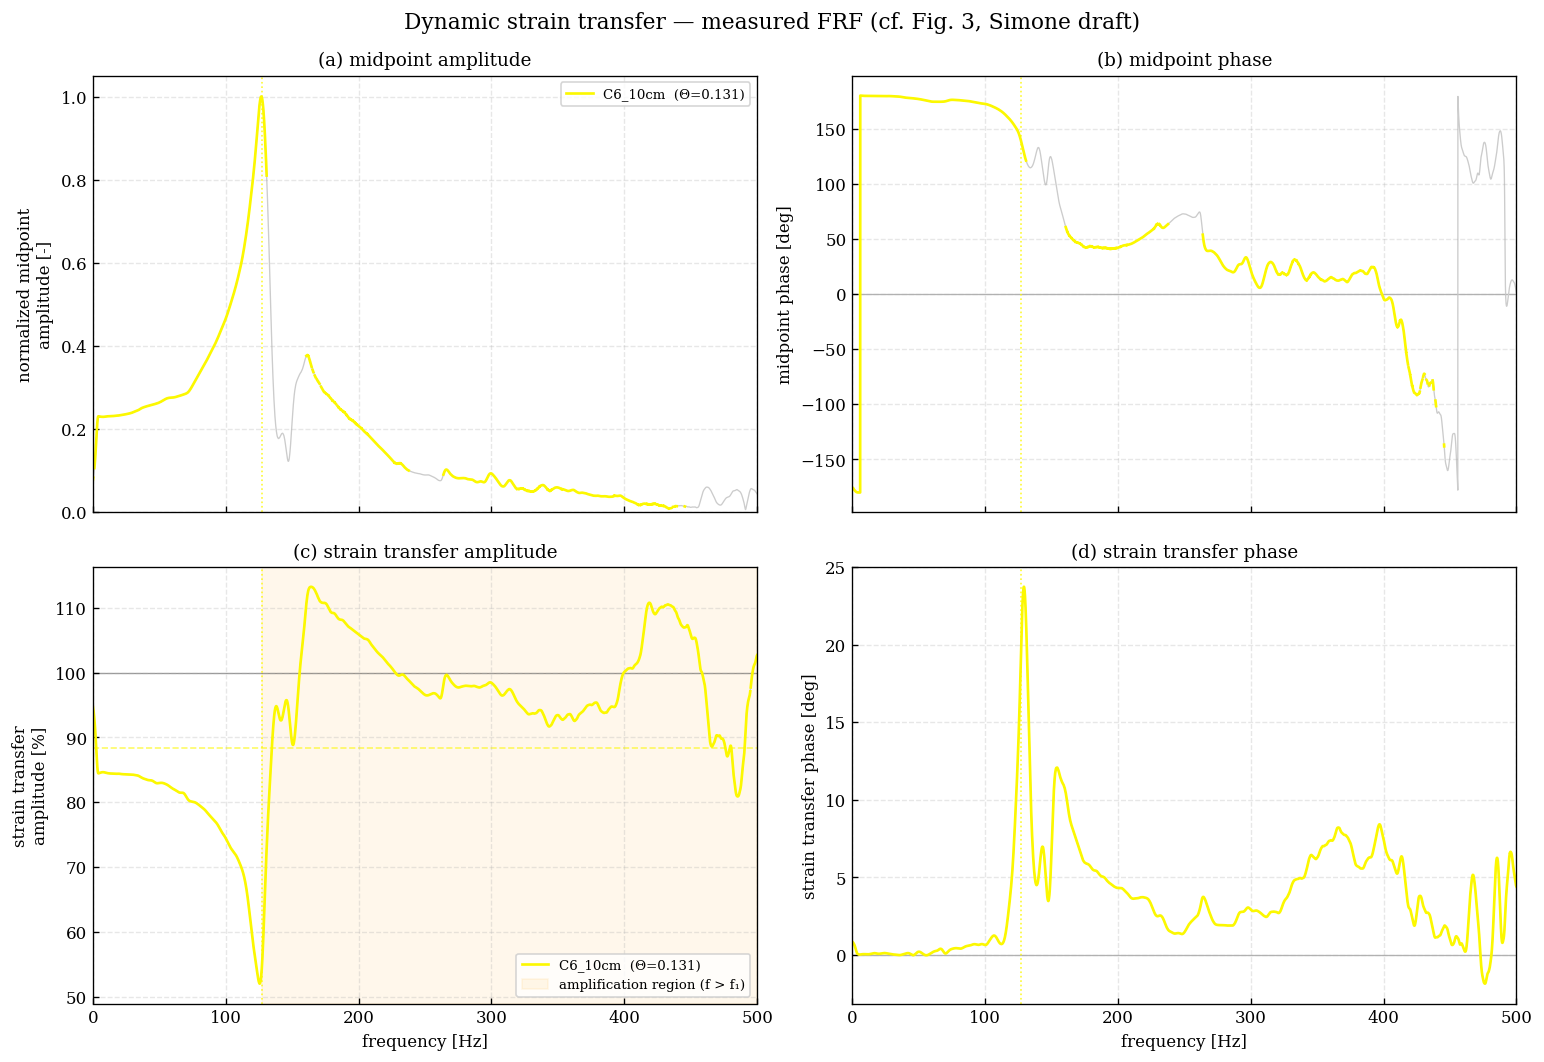

In [51]:
F_MAX_PLOT = 500.0

plotting.plot_fig3_transfer(DATASETS, f_max=F_MAX_PLOT, coh_thresh=0.7,
                            show_stft=False, show_eta_pred=True,
                            phase_mode='wrapped');

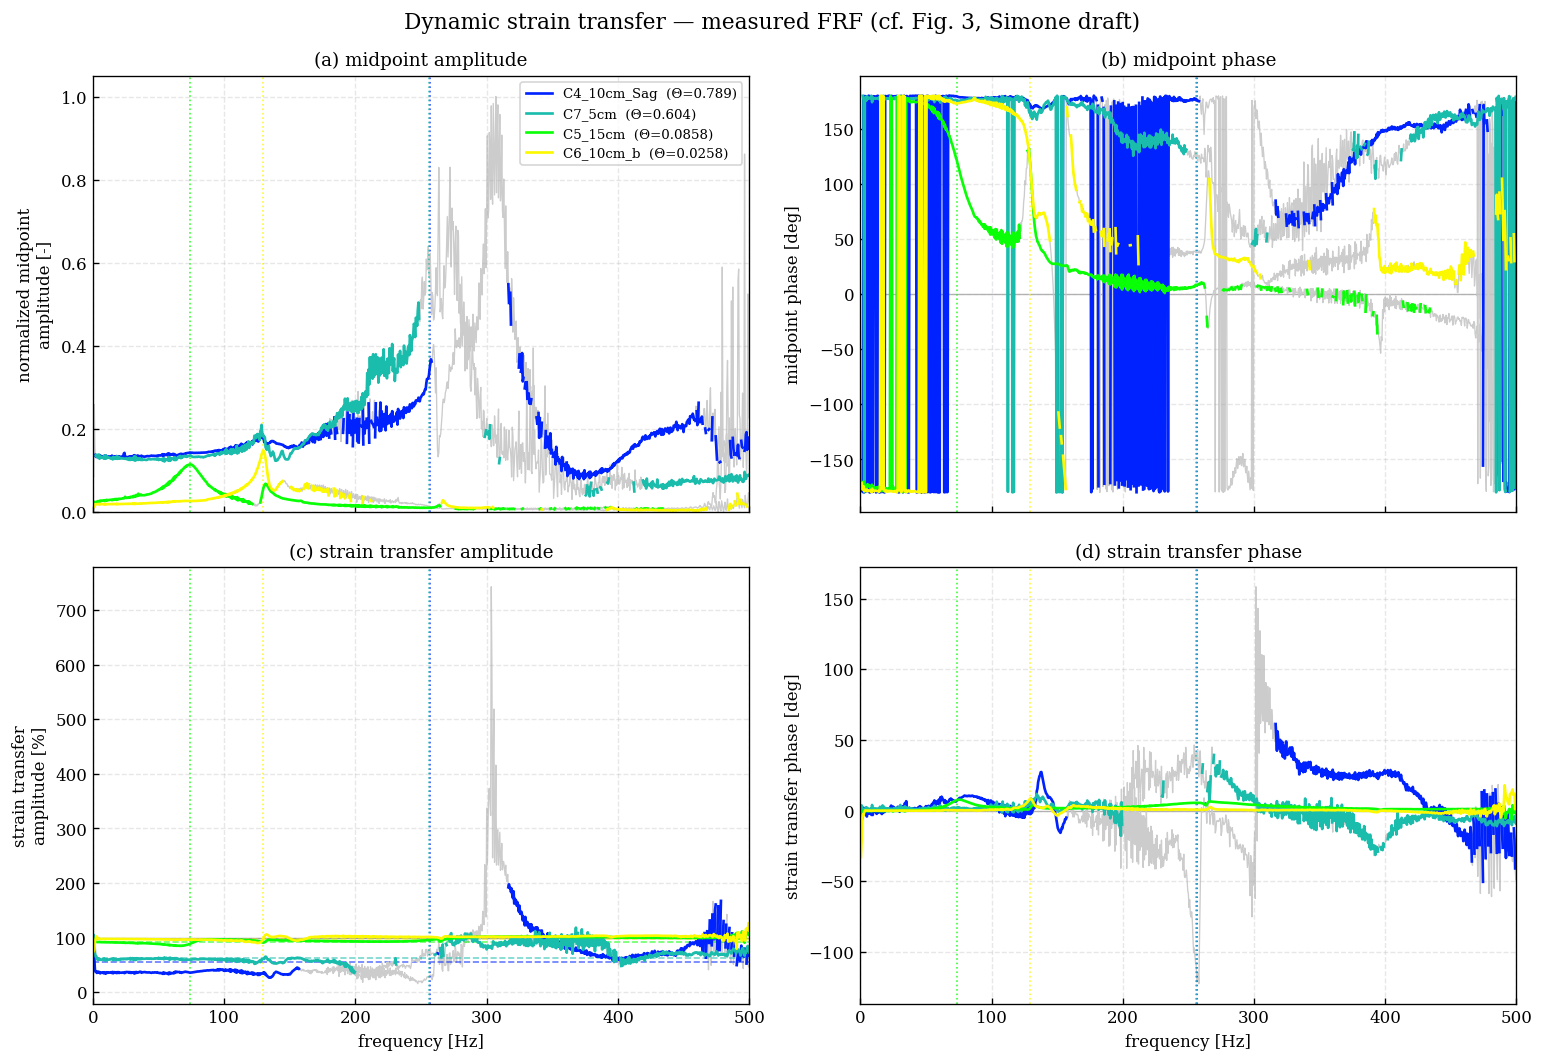

In [187]:
F_MAX_PLOT = 500.0

plotting.plot_fig3_transfer(DATASETS, f_max=F_MAX_PLOT, coh_thresh=0.7,
                            show_stft=False, show_eta_pred=True,
                            phase_mode='wrapped');

---
## § 4  Estimator comparison

The processing-chapter figure: the raw single-FFT direct ratio as the noisy
baseline (faint), the same estimate smoothed to the Welch resolution
bandwidth (dark grey), H1/H2 as the noise-on-output / noise-on-input
least-squares fits, Hv as the total-least-squares compromise, and the
coherence that explains where they diverge.

The two direct curves separate the two things that distinguish "direct" from
H1: the faint-to-dark-grey step is pure **averaging**, and whatever gap
remains between the dark grey curve and H1 is the **estimator algebra**.

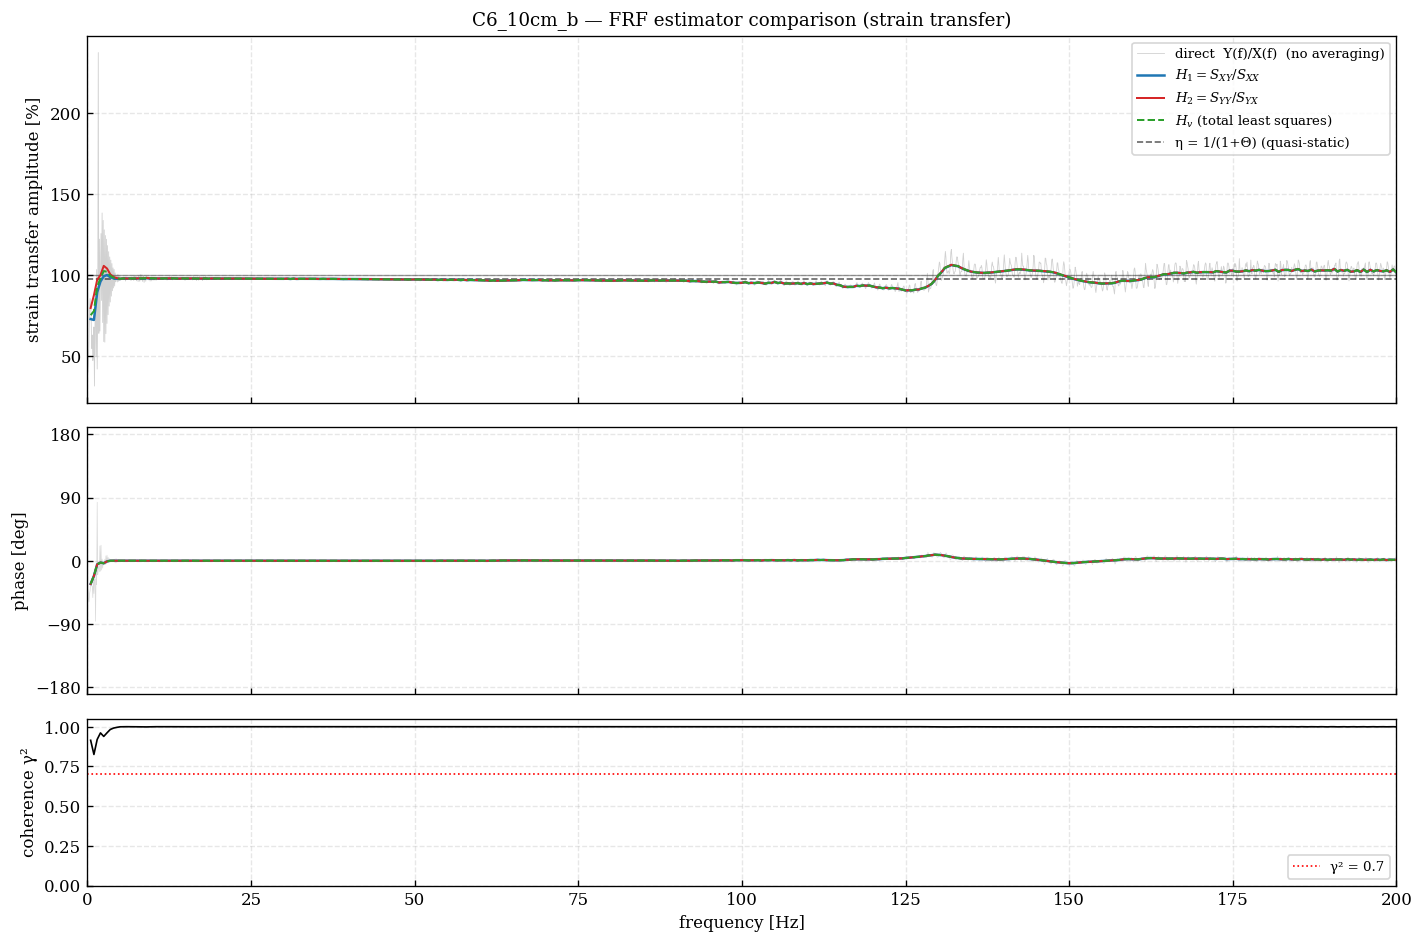

In [191]:
plotting.plot_estimator_comparison(DATASETS[3], which='eta',
                                   f_max=200.0, coh_thresh=0.7);

---
## § 5  STFT-per-frequency cross-check

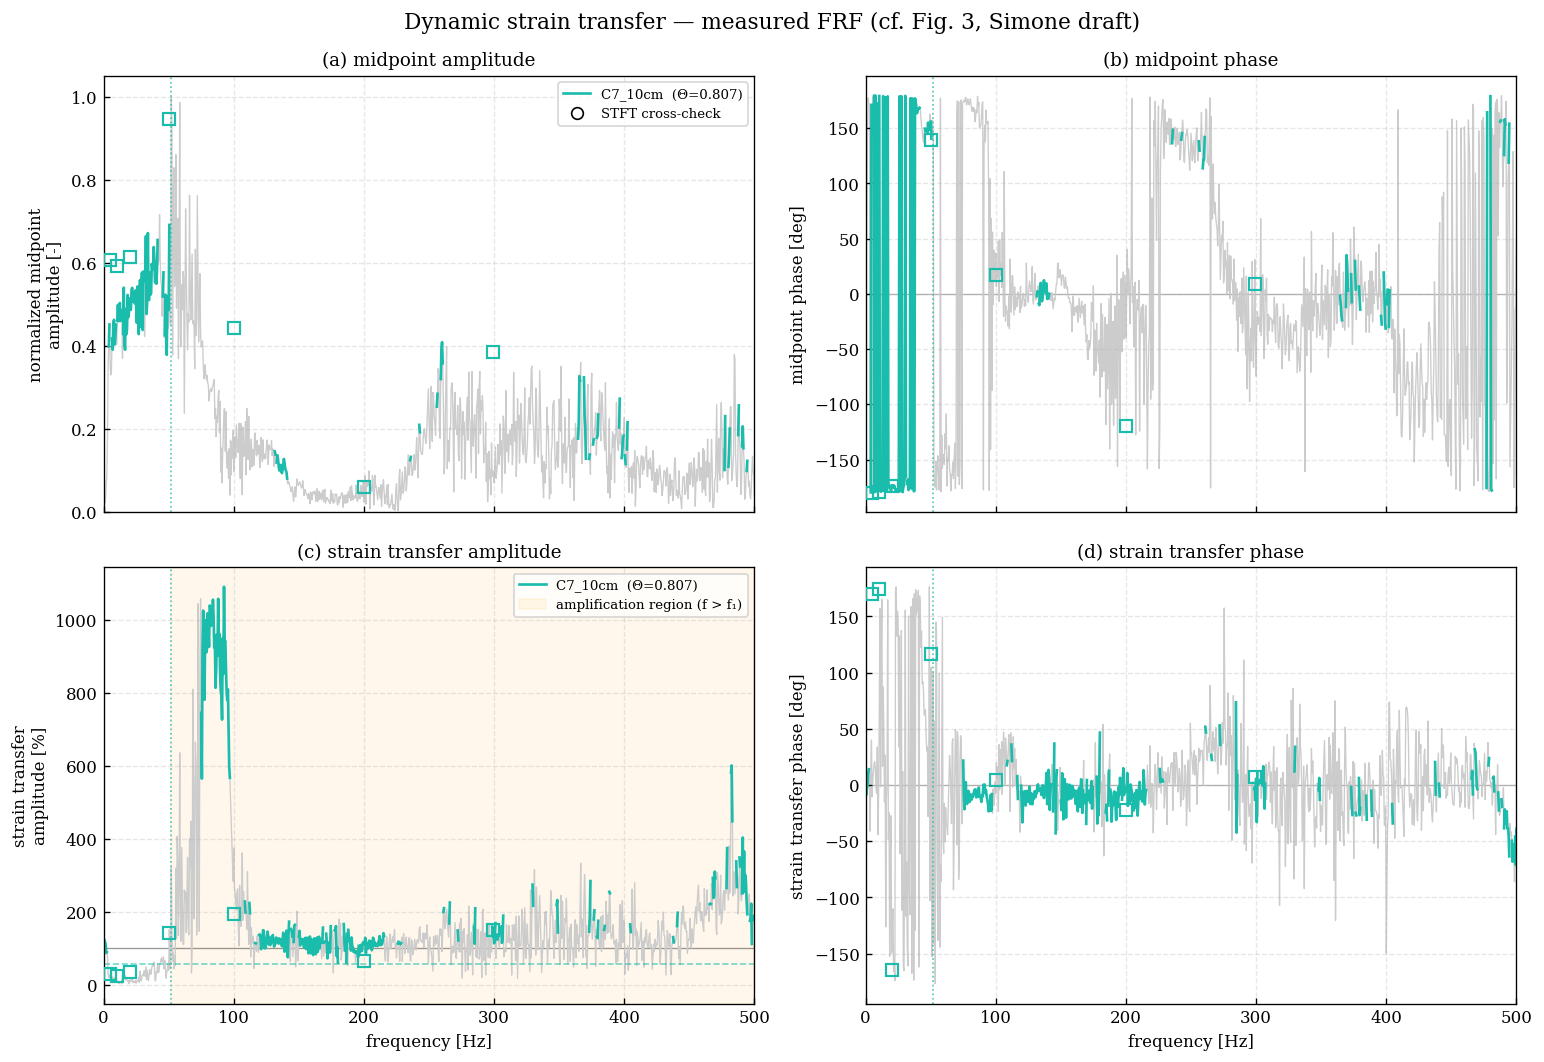

In [139]:
STFT_FREQS = [5, 10, 20, 50, 100, 200, 300]

for cfg in DATASETS:
    freqdomain.stft_point_transfers(cfg, STFT_FREQS)

plotting.plot_fig3_transfer(DATASETS, f_max=F_MAX_PLOT, coh_thresh=0.7,
                            show_stft=True, show_eta_pred=True,
                            phase_mode='wrapped');

---
## § 6  η vs Θ across all configurations

Batch: for every sweep dataset compute the coherence-gated band mean
$\eta=\langle|H_\eta(f)|\rangle$ over the quasi-static band, then scatter
against Θ with the theory curve η = 1/(1+Θ).

> First run is heavy (~42 .mat loads); cached afterwards.

In [ ]:
ETA_LABELS = config.SWEEP_LABELS
ETA_DATASETS = config.select_datasets(ETA_LABELS)

ETA_FMIN, ETA_FMAX, ETA_COH = 1.0, 25.0, 0.7
ESTIMATOR = 'hv'       # primary FRF for the η summaries:

for cfg in ETA_DATASETS:
    io.load_cable_dataset(cfg, verbose=False)
    analysis.prepare_geometry(cfg, sag_use_3d=True, sag_use_parabola=True)
    freqdomain.build_coupling_signals(cfg, x_source=X_SOURCE)
    freqdomain.compute_transfer_functions(cfg, estimator=ESTIMATOR,
                                          all_estimators=True,
                                          direct_smooth_hz=DIRECT_SMOOTH_HZ)
    em, es, n = freqdomain.band_mean_eta(cfg, ETA_FMIN, ETA_FMAX, ETA_COH)
    print(f"  {cfg['label']:20s} Θ={cfg['theta_pred']:.4g}  "
          f"η_meas={('%.3f' % em) if em is not None else ' n/a':>6}  (n={n})")

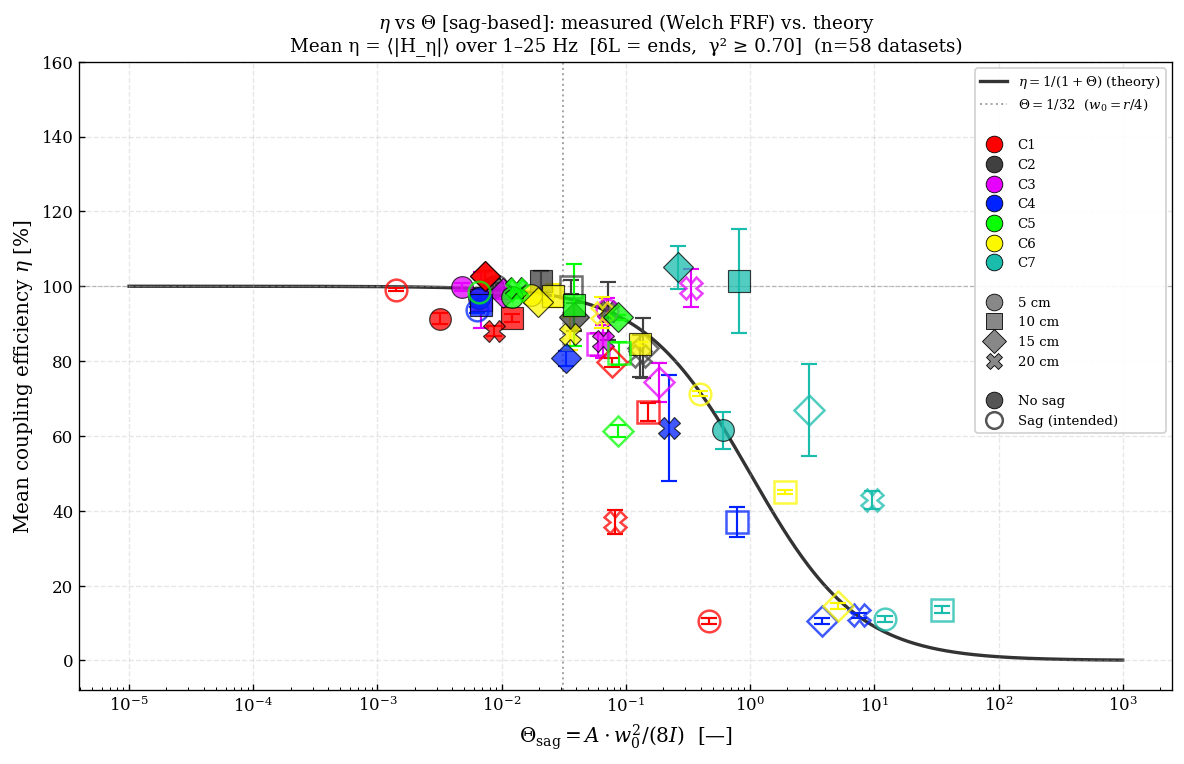

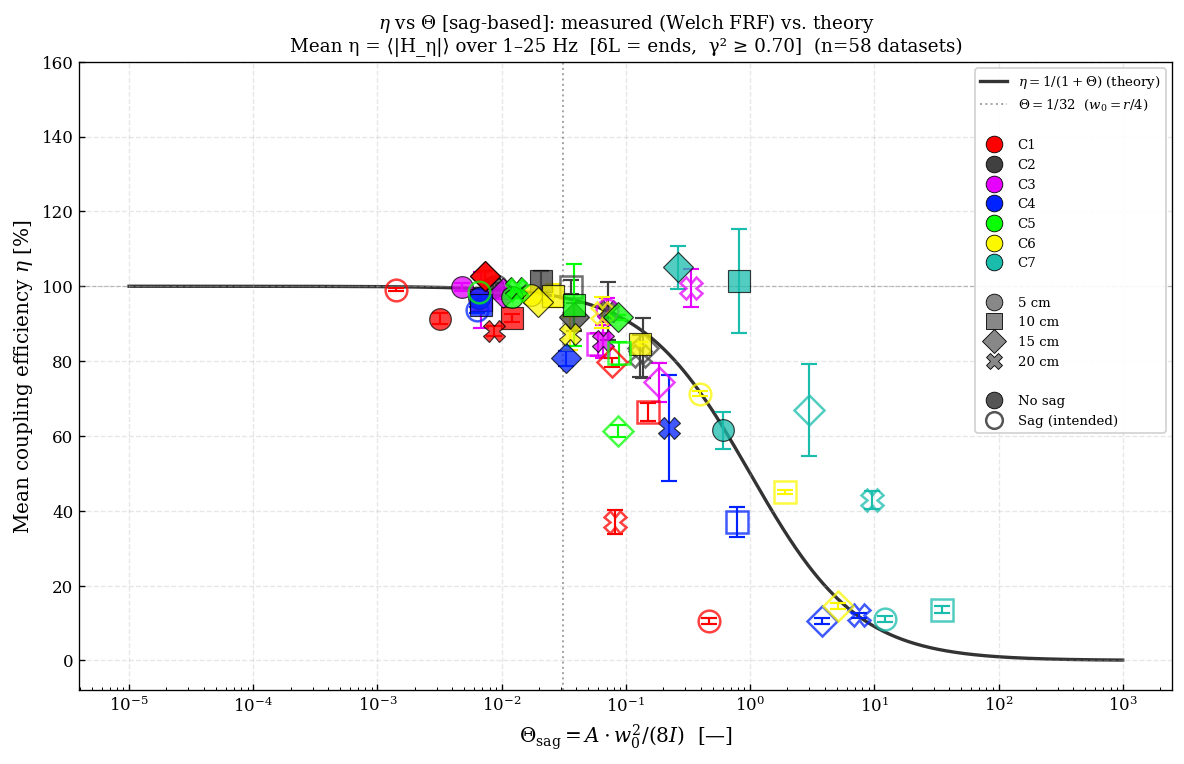

In [162]:
ETA_FMIN, ETA_FMAX, ETA_COH = 1.0, 25.0, 0.7
plotting.plot_eta_vs_theta_fd(
    ETA_DATASETS, f_min=ETA_FMIN, f_max=ETA_FMAX, coh_thresh=ETA_COH,
    theta_source='sag', x_source=X_SOURCE, percent=True)

# theta_source='material' uses Θ from ρ, E instead of the measured sag.;

---
## § 7  Export

- `freqdomain_eta.npz` — one row per configuration: Θ (both sources),
  η_pred, coherence-gated band-mean η for **each estimator** (h1/h2/hv).
- `freqdomain_frf.npz` — full FRF curves (|H|, wrapped phase, γ²) for the
  datasets selected in § 1, for the paper FRF figure.

In [ ]:
# band_mean_frf is grid-aware: the h1/h2/hv variants always live on the Welch
# grid even when the primary FRF is the direct one, so they must not be paired
# with tf['f'] by hand.

acc = dict(labels=[], cable=[], gap_m=[], is_sag_variant=[],
           theta_sag=[], theta_material=[], theta_material_std=[],
           eta_pred=[], f1_meas=[],
           eta_primary=[], eta_primary_std=[],
           eta_h1=[], eta_h1_std=[], eta_h2=[], eta_h2_std=[],
           eta_hv=[], eta_hv_std=[], n_bins=[])
for cfg in ETA_DATASETS:
    tf = cfg['fd_tf']
    acc['labels'].append(cfg['label'])
    acc['cable'].append(cfg['cable'])
    acc['gap_m'].append(cfg['gap_m'])
    acc['is_sag_variant'].append('Sag' in cfg['label'])
    acc['theta_sag'].append(cfg['theta_pred'])
    acc['theta_material'].append(cfg['theta_material'])
    acc['theta_material_std'].append(cfg['theta_material_std'])
    acc['eta_pred'].append(cfg['eta_pred'])
    res = cfg.get('fd_resonance') or {}
    acc['f1_meas'].append(res.get('f1_meas', np.nan))
    # Primary FRF (whatever ESTIMATOR selected — 'direct' included)
    m, s, n = freqdomain.band_mean_frf(tf, 'H_eta', ETA_FMIN, ETA_FMAX, ETA_COH)
    acc['eta_primary'].append(m)
    acc['eta_primary_std'].append(s)
    acc['n_bins'].append(n)
    # Averaged estimators for comparison (always on the Welch grid)
    for est in ('h1', 'h2', 'hv'):
        m, s, _ = freqdomain.band_mean_frf(tf, f'H_eta_{est}',
                                           ETA_FMIN, ETA_FMAX, ETA_COH)
        acc[f'eta_{est}'].append(m)
        acc[f'eta_{est}_std'].append(s)

acc['is_sag_variant'] = np.array(acc['is_sag_variant'])
export.export_results(
    'freqdomain_eta',
    meta=dict(band=(ETA_FMIN, ETA_FMAX), coh_thresh=ETA_COH,
              x_source=X_SOURCE, estimator_primary=tf['estimator']),
    **acc)

In [ ]:
# FRF curves of the § 1 selection.
# f is the primary grid (dense FFT for ESTIMATOR=None, Welch otherwise);
# f_welch is the grid the H_eta_h2/hv variants live on.
tf0 = DATASETS[0]['fd_tf']
export.export_results(
    'freqdomain_frf',
    meta=dict(x_source=X_SOURCE, estimator=tf0['estimator'], grid=tf0['grid'],
              nperseg=tf0['nperseg'], df=tf0['df'], coh_thresh=0.7),
    labels=[c['label'] for c in DATASETS],
    theta=[c['theta_pred'] for c in DATASETS],
    eta_pred=[c['eta_pred'] for c in DATASETS],
    f1_meas=[c['fd_resonance']['f1_meas'] for c in DATASETS],
    f=tf0['f'],
    H_eta_abs=[np.abs(c['fd_tf']['H_eta']) for c in DATASETS],
    H_eta_phase=[np.angle(c['fd_tf']['H_eta']) for c in DATASETS],
    coh_eta=[c['fd_tf']['coh_eta'] for c in DATASETS],
    H_mid_abs=[np.abs(c['fd_tf']['H_mid']) for c in DATASETS],
    H_mid_phase=[np.angle(c['fd_tf']['H_mid']) for c in DATASETS],
    coh_mid=[c['fd_tf']['coh_mid'] for c in DATASETS],
    f_welch=tf0['f_welch'],
    H_eta_h2_abs=[np.abs(c['fd_tf']['H_eta_h2']) for c in DATASETS],
    H_eta_hv_abs=[np.abs(c['fd_tf']['H_eta_hv']) for c in DATASETS],
)